## 3 этап. Проверить, как готовая VLM отвечает на вопросы из GQA-ru без дообучения.

# Baseline evaluation

Цель ноутбука — проверить качество готовой визуально-языковой модели без дополнительного обучения.

Модель получает изображение и вопрос из GQA-ru. Ответ модели сравнивается с эталонным полем answer.

Загрузим зависимоти

In [1]:
!pip install -q -U transformers accelerate datasets pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 10.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.2.0 which is incompatible.


In [2]:
!pip install -q "pillow<12.0,>=8.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 114.3 MB/s eta 0:00:00


Загрузим тестовую часть

In [3]:
from datasets import load_dataset
import pandas as pd

#загрузка тестовой части датасета
instructions = load_dataset("deepvk/GQA-ru", "train_balanced_instructions", split = "train")

#словарь для быстрого поиска по imageID
image_to_instruction = {}

for i in instructions:
    image_ID = str(i["imageId"])

    if image_ID not in image_to_instruction:
        image_to_instruction[image_ID] = []

    image_to_instruction[image_ID].append(i)

#загрузка изображений
images_stream = load_dataset("deepvk/GQA-ru", "train_balanced_images", split = "train", streaming=True)

#выборка из 50 картинок и вопросов к ним
examples = []
max_count = 50

for image_item in images_stream:
    current_image_id = str(image_item["id"])

    if current_image_id in image_to_instruction:
        instruction = image_to_instruction[current_image_id][0]

        examples.append({
            "imageId": current_image_id,
            "image": image_item["image"],
            "question": instruction["question"],
            "answer": instruction["answer"],
            "fullAnswer": instruction["fullAnswer"]
        })

        if len(examples) >= max_count:
            break

print("Amount of examples for baseline:", len(examples))


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Access to the secret `HF_TOKEN` has not been granted on this notebook.
You will not be requested again.
Please restart the session if you want to be prompted again.
  warnings.warn(


README.md:   0%|          | 0.00/5.60k [00:00<?, ?B/s]

train_balanced_instructions/train-00000-(…):   0%|          | 0.00/7.99M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/40000 [00:00<?, ? examples/s]

Amount of examples for baseline: 50


Загрузка модели

In [4]:
!pip install -q -U qwen-vl-utils

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.4/35.4 MB 65.9 MB/s eta 0:00:00


In [5]:
import torch

from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
from qwen_vl_utils import process_vision_info

In [6]:
model_name = "Qwen/Qwen2-VL-2B-Instruct"

model = Qwen2VLForConditionalGeneration.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto"
)

processor = AutoProcessor.from_pretrained(model_name)

model.eval()

config.json:   0%|          | 0.00/1.20k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/56.4k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

Qwen2VLForConditionalGeneration(
  (model): Qwen2VLModel(
    (visual): Qwen2VisionTransformerPretrainedModel(
      (patch_embed): PatchEmbed(
        (proj): Conv3d(3, 1280, kernel_size=(2, 14, 14), stride=(2, 14, 14), bias=False)
      )
      (rotary_pos_emb): VisionRotaryEmbedding()
      (blocks): ModuleList(
        (0-31): 32 x Qwen2VLVisionBlock(
          (norm1): LayerNorm((1280,), eps=1e-06, elementwise_affine=True)
          (norm2): LayerNorm((1280,), eps=1e-06, elementwise_affine=True)
          (attn): VisionAttention(
            (qkv): Linear(in_features=1280, out_features=3840, bias=True)
            (proj): Linear(in_features=1280, out_features=1280, bias=True)
          )
          (mlp): VisionMlp(
            (fc1): Linear(in_features=1280, out_features=5120, bias=True)
            (act): QuickGELUActivation()
            (fc2): Linear(in_features=5120, out_features=1280, bias=True)
          )
        )
      )
      (merger): PatchMerger(
        (ln_q): LayerN

In [7]:
def generate_answer(image, question, max_new_tokens=20):
    messages = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": image
                },
                {
                    "type": "text",
                    "text": f"Вопрос: {question}\nОтветь одним словом."
                }
            ]
        }
    ]

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    image_inputs, video_inputs = process_vision_info(messages)

    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt"
    )

    inputs = inputs.to(model.device)

    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False
        )

    generated_ids_trimmed = [
        output_ids[len(input_ids):]
        for input_ids, output_ids in zip(inputs.input_ids, generated_ids)
    ]

    output_text = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )

    return output_text[0].strip()

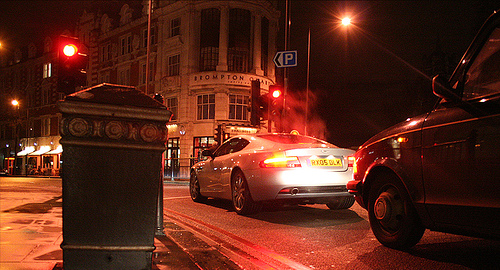

Question: Машина справа от другой машины стоит или едет?
True answer: стоит
Model answer: стоят


In [8]:
ex = examples[0]

display(ex["image"])
print("Question:", ex["question"])
print("True answer:", ex["answer"])

model_answer = generate_answer(ex["image"], ex["question"])
print("Model answer:", model_answer)

In [9]:
#функция нормальзации ответа

def normalize_answer(text):
    text = str(text).lower().strip()
    text = text.replace("ё", "е")
    text = text.strip(" .,!?:;\"'«»")
    return text

In [10]:
results = []

for ex in examples:
    model_answer = generate_answer(ex["image"], ex["question"])

    true_norm = normalize_answer(ex["answer"])
    pred_norm = normalize_answer(model_answer)

    results.append({
        "imageId": ex["imageId"],
        "question": ex["question"],
        "true_answer": ex["answer"],
        "model_answer": model_answer,
        "true_norm": true_norm,
        "pred_norm": pred_norm,
        "is_correct": true_norm == pred_norm
    })

results_df = pd.DataFrame(results)
results_df

,imageId,question,true_answer,model_answer,true_norm,pred_norm,is_correct
0,2354786,Машина справа от другой машины стоит или едет?,стоит,стоят,стоит,стоят,False
1,2375429,Дверь сделана из металла или дерева?,дерево,дерево,дерево,дерево,True
2,2331819,"Какой материал используется для пола, который ...",древесина,бетон,древесина,бетон,False
3,2324496,Есть ли подушки или книги?,да,нет,да,нет,False
4,2410353,Деревянный кофейный столик слева или справа от...,слева,слева,слева,слева,True
5,2322142,Как называется черный предмет одежды?,рубашка,рубашка,рубашка,рубашка,True
6,2328505,С какой стороны изображения находится ловец?,слева,слева,слева,слева,True
7,2347082,"Какого цвета, по твоему мнению, небо?",темного,черное,темного,черное,False
8,2377188,Есть ли на картине куры или заборы?,нет,нет,нет,нет,True
9,2378822,"В сцене есть и краны, и кофеварки?",да,нет,да,нет,False


In [11]:
exact_match = results_df["is_correct"].mean()
print(f"Exact Match: {exact_match:.3f}")

Exact Match: 0.440


In [12]:
errors_df = results_df[results_df["is_correct"] == False]
errors_df[["question", "true_answer", "model_answer"]]

,question,true_answer,model_answer
0,Машина справа от другой машины стоит или едет?,стоит,стоят
2,"Какой материал используется для пола, который ...",древесина,бетон
3,Есть ли подушки или книги?,да,нет
7,"Какого цвета, по твоему мнению, небо?",темного,черное
9,"В сцене есть и краны, и кофеварки?",да,нет
12,Лыжник в перчатке?,нет,Да
14,Какой вес у стула?,тяжёлый,несколько килограммов
15,Что это за место?,поле,ферма
19,В чем кот?,в чашке,чашка
20,На чём лежит салфетка?,на столе,сумка


## Вывод

На выборке из 50 примеров модель Qwen2-VL-2B-Instruct получила Exact Match = 0.44.

Модель корректно ответила на часть вопросов, связанных с материалами, расположением и объектами. Ошибки возникли в вопросах про состояние объекта, материал пола, наличие объектов и цвет.
Полученный результат используется как baseline для дальнейшего сравнения с дообученной моделью. Анализ ошибок показывает, какие типы вопросов вызывают наибольшие трудности.